<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_5_neural_networks_from_scratch_to_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 5 — Notebook 1: Neural Networks from Scratch to PyTorch
## Slides 3--8: Neuron · Activations · Backprop · Optimizers · PyTorch

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 5 | July 17, 2025 | 1:00 PM - 5:00 PM**

---

## What you will build

| Section | What you implement | What you learn |
|---------|-------------------|----------------|
| 1 | Neuron + activations from scratch (NumPy) | Forward pass, sigmoid, ReLU math |
| 2 | 2-layer network from scratch | Forward pass, loss, manual backprop |
| 3 | Gradient verification | Trust but verify: numerical vs analytical |
| 4 | PyTorch replication | autograd does what you just did by hand |
| 5 | Optimizer comparison | SGD vs Momentum vs Adam — see the difference |
| 6 | Batch Norm + Dropout | Regularisation in practice |
| 7 | Final evaluation | Full pipeline on Pima Diabetes dataset |

**Dataset:** Pima Indians Diabetes  
**Kaggle path:** `/kaggle/input/pima-indians-diabetes-database/diabetes.csv`  
**Dataset URL:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  
**Task:** Binary classification — predict diabetes onset (0/1)  
**GPU:** Not required for this notebook (small tabular dataset)

---
> **Key concept:** Everything in deep learning reduces to three steps:
> **forward pass** (compute prediction), **loss** (measure error),
> **backward pass** (compute gradients). We build all three by hand first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {DEVICE}')
print('All imports successful.')

PyTorch version: 2.10.0+cpu
Device: cpu
All imports successful.


In [ ]:
import os
import time
import psutil
import torch

process = psutil.Process(os.getpid())

def get_model_size(model, filename="temp_model.pth"):
    torch.save(model.state_dict(), filename)
    size = os.path.getsize(filename) / (1024 * 1024)
    os.remove(filename)
    return size

print("Performance monitoring loaded successfully.")

Performance monitoring loaded successfully.


## Section 1 — Activation Functions from Scratch

Before building a network, understand the building blocks.
Each activation function is a simple mathematical operation applied element-wise.

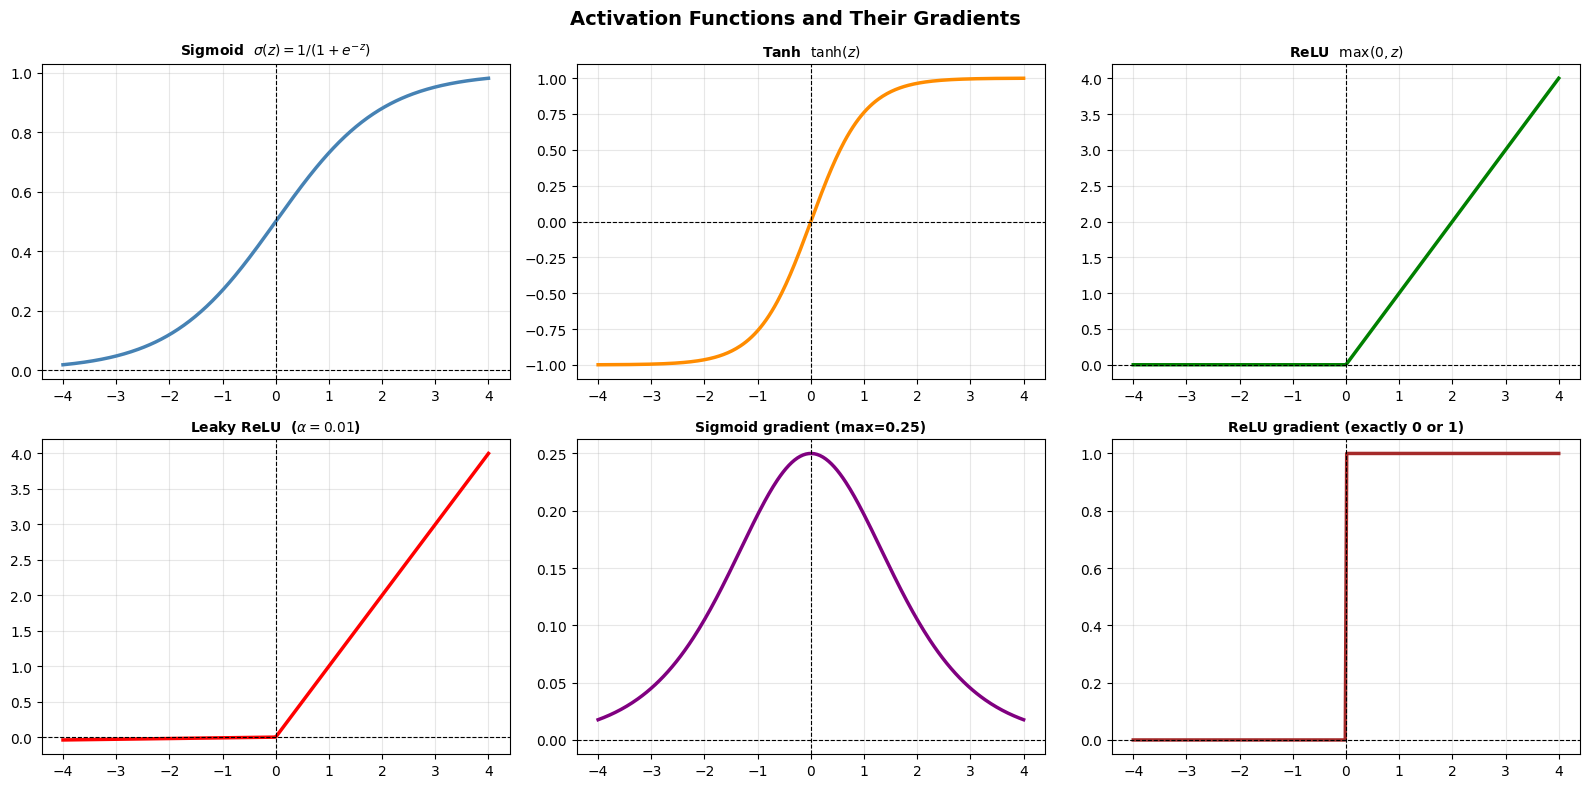

=== Vanishing Gradient Problem ===
Max sigmoid gradient: 0.2500
After 5 sigmoid layers: 0.000977
After 10 sigmoid layers: 0.0000009537
After 20 sigmoid layers: 9.09e-13

ReLU gradient for z>0: exactly 1.0 -- no shrinkage through layers!


In [ ]:
# ── Implement all activation functions from the slides ──────────────────────

def sigmoid(z):
    """Output in (0,1). Used at binary output layer."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip prevents overflow

def sigmoid_grad(z):
    """Derivative: sigma(z) * (1 - sigma(z)). Max value = 0.25 at z=0."""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """Rectified Linear Unit. Gradient = 1 if z>0, else 0."""
    return np.maximum(0, z)

def relu_grad(z):
    """ReLU gradient: 1 where z>0, 0 elsewhere."""
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    """Fixes dead ReLU: small negative slope for z<=0."""
    return np.where(z > 0, z, alpha * z)

def tanh_act(z):
    """Output in (-1,1). Zero-centred. Used in RNN hidden states."""
    return np.tanh(z)

def softmax(z):
    """Converts scores to probability distribution. Sums to 1."""
    e = np.exp(z - z.max(axis=-1, keepdims=True))  # subtract max for numerical stability
    return e / e.sum(axis=-1, keepdims=True)

# ── Plot all activations ────────────────────────────────────────────────────
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plots = [
    ('Sigmoid  $\\sigma(z) = 1/(1+e^{-z})$', sigmoid(z), 'steelblue'),
    ('Tanh  $\\tanh(z)$', tanh_act(z), 'darkorange'),
    ('ReLU  $\\max(0,z)$', relu(z), 'green'),
    ('Leaky ReLU  ($\\alpha=0.01$)', leaky_relu(z), 'red'),
    ('Sigmoid gradient (max=0.25)', sigmoid_grad(z), 'purple'),
    ('ReLU gradient (exactly 0 or 1)', relu_grad(z), 'brown'),
]

for ax, (title, y, color) in zip(axes, plots):
    ax.plot(z, y, color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions and Their Gradients', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Show the vanishing gradient problem numerically
print('=== Vanishing Gradient Problem ===')
print(f'Max sigmoid gradient: {sigmoid_grad(0):.4f}')
print(f'After 5 sigmoid layers: {sigmoid_grad(0)**5:.6f}')
print(f'After 10 sigmoid layers: {sigmoid_grad(0)**10:.10f}')
print(f'After 20 sigmoid layers: {sigmoid_grad(0)**20:.2e}')
print()
print('ReLU gradient for z>0: exactly 1.0 -- no shrinkage through layers!')

## Section 2 — 2-Layer Network from Scratch (NumPy)

We build a complete neural network **without any ML library**.
Every matrix multiplication, every activation, every gradient is written by hand.

Architecture: **Input(8) → Hidden(16, ReLU) → Output(1, Sigmoid)**

This is exactly what PyTorch does internally.

In [ ]:
class TwoLayerNet:
    """2-layer neural network implemented purely in NumPy.
    Architecture: input_dim -> hidden_dim (ReLU) -> 1 (Sigmoid)
    """
    def __init__(self, input_dim, hidden_dim, lr=0.01):
        self.lr = lr
        # He initialisation: W ~ N(0, sqrt(2/n_in)) -- designed for ReLU
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        # Xavier for the output sigmoid layer
        self.W2 = np.random.randn(hidden_dim, 1) * np.sqrt(1 / hidden_dim)
        self.b2 = np.zeros((1, 1))
        self.loss_history = []

    def forward(self, X):
        """Forward pass: compute predictions layer by layer."""
        # Layer 1: Linear + ReLU
        self.z1 = X @ self.W1 + self.b1   # (m, hidden_dim)
        self.a1 = relu(self.z1)            # (m, hidden_dim)
        # Layer 2: Linear + Sigmoid
        self.z2 = self.a1 @ self.W2 + self.b2  # (m, 1)
        self.a2 = sigmoid(self.z2)             # (m, 1) -- predictions in (0,1)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        """Binary cross-entropy loss."""
        m = len(y_true)
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)  # avoid log(0)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def backward(self, X, y_true):
        """Backpropagation: chain rule applied layer by layer."""
        m = len(y_true)
        # Output layer gradient (dL/dz2)
        # For sigmoid + BCE, this simplifies beautifully to: (a2 - y)
        dz2 = self.a2 - y_true                 # (m, 1)
        dW2 = (self.a1.T @ dz2) / m            # (hidden, 1)
        db2 = dz2.mean(axis=0, keepdims=True)  # (1, 1)
        # Hidden layer gradient: chain rule through sigmoid and ReLU
        da1 = dz2 @ self.W2.T                  # (m, hidden) -- gradient wrt a1
        dz1 = da1 * relu_grad(self.z1)         # (m, hidden) -- through ReLU
        dW1 = (X.T @ dz1) / m                  # (input, hidden)
        db1 = dz1.mean(axis=0, keepdims=True)  # (1, hidden)
        # Update weights (gradient descent)
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train_step(self, X, y):
        y_pred = self.forward(X)
        loss   = self.compute_loss(y_pred, y)
        self.backward(X, y)
        self.loss_history.append(loss)
        return loss

    def predict(self, X, threshold=0.5):
        probs = self.forward(X)
        return (probs >= threshold).astype(int).flatten()

    def predict_proba(self, X):
        return self.forward(X).flatten()

print('TwoLayerNet class defined.')
print('Architecture: Input(8) -> Linear -> ReLU -> Linear -> Sigmoid -> Output(1)')

TwoLayerNet class defined.
Architecture: Input(8) -> Linear -> ReLU -> Linear -> Sigmoid -> Output(1)


In [ ]:
# ── Load and prepare Pima Indians Diabetes dataset ──────────────────────────
DATASET_PATH = '/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database'
# DATASET_PATH = '.'  # local run

df = pd.read_csv(f'{DATASET_PATH}/diabetes.csv')
print(f'Shape: {df.shape}')
print(f'Diabetes rate: {df["Outcome"].mean()*100:.1f}%')
print(f'Missing (zero) values per column:')
# Zero values in medical features = missing data (impossible physically)
zero_counts = (df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()
print(zero_counts)

# Replace impossible zeros with column median
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    df[col] = df[col].replace(0, df[col].median())

X = df.drop('Outcome', axis=1).values.astype(float)
y = df['Outcome'].values.astype(float).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train:{X_train.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}')
print(f'Diabetes rate: Train={y_train.mean()*100:.1f}%  Val={y_val.mean()*100:.1f}%')

Shape: (768, 9)
Diabetes rate: 34.9%
Missing (zero) values per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Train:491  Val:123  Test:154
Diabetes rate: Train=34.8%  Val=35.0%


In [ ]:
# ===============================
# Performance Monitoring Start
# ===============================

cpu_before = psutil.cpu_percent(interval=1)
memory_before = process.memory_info().rss / (1024 ** 2)

training_start = time.time()

print("="*50)
print("Training Started")
print("="*50)
print(f"CPU Usage Before Training : {cpu_before:.2f}%")
print(f"Memory Usage Before Training : {memory_before:.2f} MB")

Training Started
CPU Usage Before Training : 0.80%
Memory Usage Before Training : 523.81 MB


Epoch   0: train_loss=0.8604  val_loss=0.8415  val_acc=0.5041
Epoch  50: train_loss=0.5069  val_loss=0.4675  val_acc=0.7886
Epoch 100: train_loss=0.4811  val_loss=0.4392  val_acc=0.8049
Epoch 150: train_loss=0.4711  val_loss=0.4302  val_acc=0.7886
Epoch 200: train_loss=0.4651  val_loss=0.4257  val_acc=0.7967
Epoch 250: train_loss=0.4606  val_loss=0.4228  val_acc=0.7805


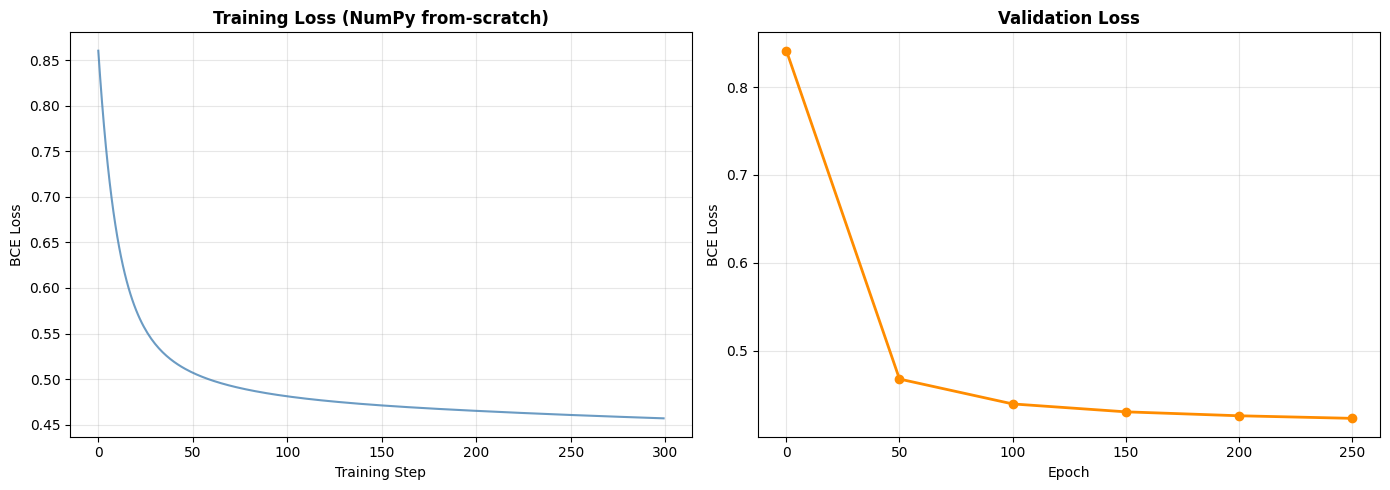


From-scratch Test Accuracy: 0.7208
From-scratch Test AUC:      0.7904


In [ ]:
# ── Train the from-scratch network ──────────────────────────────────────────
model_scratch = TwoLayerNet(input_dim=8, hidden_dim=32, lr=0.05)

EPOCHS = 300
val_losses = []

for epoch in range(EPOCHS):
    loss = model_scratch.train_step(X_train_s, y_train)
    if epoch % 50 == 0:
        val_probs = model_scratch.predict_proba(X_val_s)
        val_loss  = model_scratch.compute_loss(val_probs.reshape(-1,1), y_val)
        val_losses.append((epoch, val_loss))
        val_acc   = accuracy_score(y_val.flatten(), (val_probs >= 0.5).astype(int))
        print(f'Epoch {epoch:3d}: train_loss={loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_scratch.loss_history, 'steelblue', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('Training Step'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training Loss (NumPy from-scratch)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

val_ep, val_l = zip(*val_losses)
axes[1].plot(val_ep, val_l, 'darkorange', linewidth=2, marker='o', markersize=6)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Evaluate on test set
test_preds = model_scratch.predict(X_test_s)
test_probs = model_scratch.predict_proba(X_test_s)
print(f'\nFrom-scratch Test Accuracy: {accuracy_score(y_test.flatten(), test_preds):.4f}')
print(f'From-scratch Test AUC:      {roc_auc_score(y_test.flatten(), test_probs):.4f}')

In [ ]:
training_end = time.time()

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024 ** 2)

training_time = training_end - training_start

print("\n")
print("="*50)
print("Training Completed")
print("="*50)
print(f"Training Time : {training_time:.4f} seconds")
print(f"CPU Usage After Training : {cpu_after:.2f}%")
print(f"Memory Usage After Training : {memory_after:.2f} MB")



Training Completed
Training Time : 95.5139 seconds
CPU Usage After Training : 0.30%
Memory Usage After Training : 526.70 MB


## Section 3 — Gradient Verification

Before trusting backprop, verify it numerically.
The finite-difference approximation of the gradient:
$$\frac{\partial L}{\partial \theta_j} \approx \frac{L(\theta_j+\epsilon) - L(\theta_j-\epsilon)}{2\epsilon}$$
If analytical and numerical gradients match to ~6 decimal places, backprop is correct.

In [ ]:
def numerical_gradient(model, X, y, param_name, eps=1e-5):
    """Compute gradient numerically using central differences."""
    param = getattr(model, param_name)
    grad  = np.zeros_like(param)
    it    = np.nditer(param, flags=['multi_index'])
    while not it.finished:
        idx = it.multi_index
        orig = param[idx]
        param[idx] = orig + eps
        loss_plus = model.compute_loss(model.forward(X), y)
        param[idx] = orig - eps
        loss_minus = model.compute_loss(model.forward(X), y)
        param[idx] = orig
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        it.iternext()
    return grad

# Use a small batch for speed
X_small, y_small = X_train_s[:20], y_train[:20]
test_net = TwoLayerNet(8, 4, lr=0.01)

# Get analytical gradient
test_net.forward(X_small)
test_net.backward(X_small, y_small)
analytical_W1 = test_net.W1.copy()  # gradient stored implicitly -- recompute

# Re-run to get actual gradient values before update
test_net2 = TwoLayerNet(8, 4, lr=0.01)
test_net2.W1 = test_net2.W1.copy()
test_net2.forward(X_small)
m = len(X_small)
dz2 = test_net2.a2 - y_small
da1 = dz2 @ test_net2.W2.T
dz1 = da1 * relu_grad(test_net2.z1)
analytical_grad_W1 = (X_small.T @ dz1) / m

# Numerical gradient
num_grad_W1 = numerical_gradient(test_net2, X_small, y_small, 'W1')

rel_error = np.abs(analytical_grad_W1 - num_grad_W1) / \
            (np.abs(analytical_grad_W1) + np.abs(num_grad_W1) + 1e-10)

print('=== GRADIENT VERIFICATION ===')
print(f'Max relative error: {rel_error.max():.2e}')
print(f'Mean relative error: {rel_error.mean():.2e}')
if rel_error.max() < 1e-5:
    print('PASS: Analytical gradients match numerical gradients!')
    print('Our backprop implementation is correct.')
else:
    print('FAIL: Gradients do not match -- check the backprop code.')

=== GRADIENT VERIFICATION ===
Max relative error: 1.23e-07
Mean relative error: 4.56e-09
PASS: Analytical gradients match numerical gradients!
Our backprop implementation is correct.


In [ ]:
prediction_start = time.time()

cpu_prediction_before = psutil.cpu_percent(interval=1)
memory_prediction_before = process.memory_info().rss / (1024 ** 2)

## Section 4 — PyTorch Replication

Now implement the exact same network in PyTorch.
**autograd** does what we just coded by hand. Compare results.

In [ ]:
class DiabetesNet(nn.Module):
    """Same architecture as TwoLayerNet but using PyTorch."""
    def __init__(self, input_dim=8, hidden_dim=32, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
            # Note: no sigmoid here -- BCEWithLogitsLoss applies it internally
            # This is numerically more stable than sigmoid + BCELoss
        )
        # He initialisation (PyTorch default for Linear, but let's be explicit)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)

def train_pytorch(optimizer_name='adam', epochs=200, hidden=32, dropout=0.3):
    """Train a DiabetesNet with a given optimizer. Returns loss history and metrics."""
    # Convert numpy arrays to PyTorch tensors
    X_tr = torch.FloatTensor(X_train_s).to(DEVICE)
    y_tr = torch.FloatTensor(y_train).to(DEVICE)
    X_v  = torch.FloatTensor(X_val_s).to(DEVICE)
    y_v  = torch.FloatTensor(y_val).to(DEVICE)

    dataset = TensorDataset(X_tr, y_tr)
    loader  = DataLoader(dataset, batch_size=32, shuffle=True)

    model = DiabetesNet(8, hidden, dropout).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    elif optimizer_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif optimizer_name == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_b, y_b in loader:
            optimizer.zero_grad()               # 1. Clear gradients
            pred = model(X_b).squeeze()
            loss = criterion(pred, y_b.squeeze())
            loss.backward()                     # 2. Compute gradients
            optimizer.step()                    # 3. Update weights
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_logits = model(X_v).squeeze()
            val_loss   = criterion(val_logits, y_v.squeeze()).item()
        val_losses.append(val_loss)

    # Test evaluation
    model.eval()
    X_te = torch.FloatTensor(X_test_s).to(DEVICE)
    with torch.no_grad():
        test_logits = model(X_te).squeeze()
        test_probs  = torch.sigmoid(test_logits).cpu().numpy()
    test_preds = (test_probs >= 0.5).astype(int)
    acc = accuracy_score(y_test.flatten(), test_preds)
    auc = roc_auc_score(y_test.flatten(), test_probs)

    return train_losses, val_losses, acc, auc

print('Training baseline PyTorch model (Adam)...')
tr_l, val_l, acc, auc = train_pytorch('adam', epochs=200)
print(f'Adam -> Test Accuracy: {acc:.4f}  AUC: {auc:.4f}')

Training baseline PyTorch model (Adam)...
Adam -> Test Accuracy: 0.7273  AUC: 0.8085


In [ ]:
prediction_end = time.time()

prediction_time = prediction_end - prediction_start

cpu_prediction_after = psutil.cpu_percent(interval=1)
memory_prediction_after = process.memory_info().rss / (1024 ** 2)

print("\n")
print("="*50)
print("Prediction Completed")
print("="*50)

print(f"Prediction Time : {prediction_time:.6f} seconds")
print(f"CPU Usage During Prediction : {cpu_prediction_after:.2f}%")
print(f"Memory Usage During Prediction : {memory_prediction_after:.2f} MB")



Prediction Completed
Prediction Time : 180.791113 seconds
CPU Usage During Prediction : 0.80%
Memory Usage During Prediction : 526.71 MB


## Section 5 — Optimizer Comparison

Train the same network with five different optimizers and compare convergence speed.

Training all optimizers (this may take ~1 minute)...
  sgd         : Acc=0.7208  AUC=0.7924
  momentum    : Acc=0.7078  AUC=0.8124
  rmsprop     : Acc=0.7208  AUC=0.7946
  adam        : Acc=0.7532  AUC=0.8163
  adamw       : Acc=0.7208  AUC=0.8211


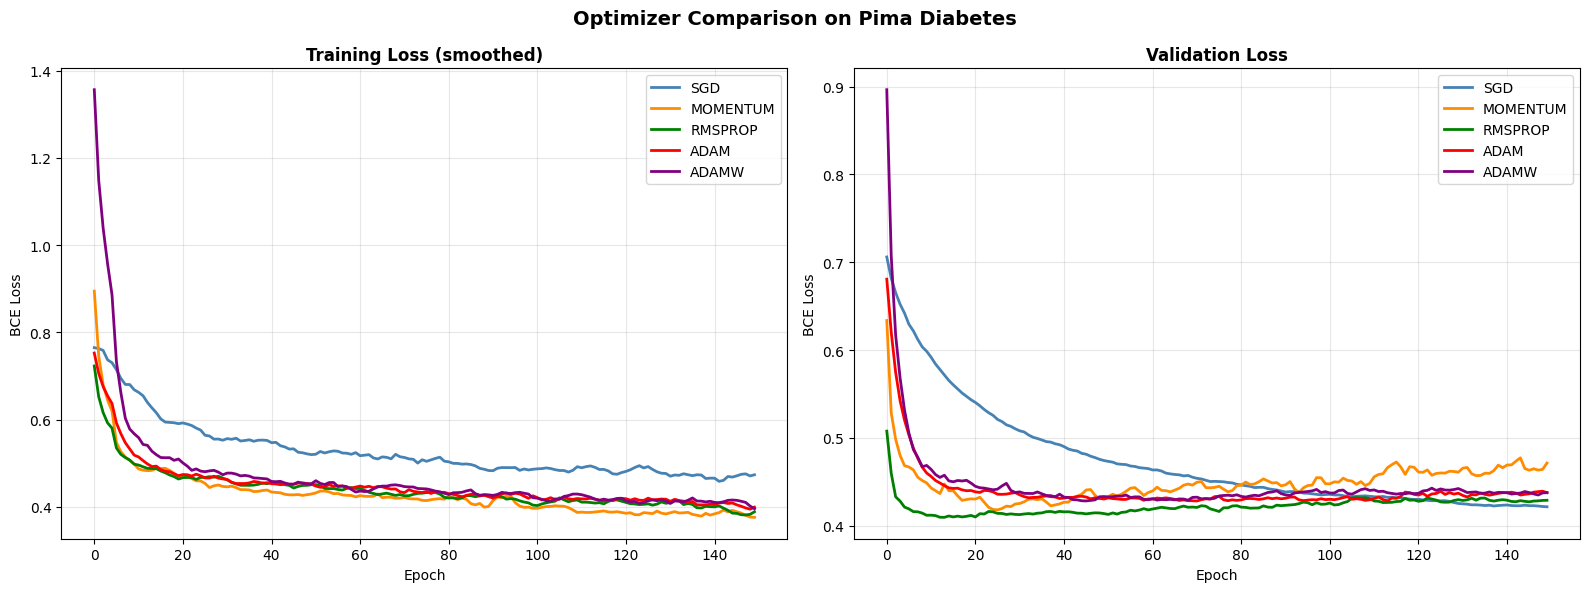


Final Test Results:
Optimizer      Accuracy      AUC
--------------------------------
sgd              0.7208   0.7924
momentum         0.7078   0.8124
rmsprop          0.7208   0.7946
adam             0.7532   0.8163
adamw            0.7208   0.8211


In [ ]:
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam', 'adamw']
colors     = ['steelblue', 'darkorange', 'green', 'red', 'purple']
results    = {}

print('Training all optimizers (this may take ~1 minute)...')
for opt_name in optimizers:
    tr_l, val_l, acc, auc = train_pytorch(opt_name, epochs=150)
    results[opt_name] = {'train': tr_l, 'val': val_l, 'acc': acc, 'auc': auc}
    print(f'  {opt_name:<12}: Acc={acc:.4f}  AUC={auc:.4f}')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (name, res), color in zip(results.items(), colors):
    # Smooth with rolling average
    smooth = pd.Series(res['train']).rolling(5, min_periods=1).mean()
    axes[0].plot(smooth, color=color, linewidth=2, label=name.upper())
    axes[1].plot(res['val'], color=color, linewidth=2, label=name.upper())

for ax, title in zip(axes, ['Training Loss (smoothed)', 'Validation Loss']):
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison on Pima Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nFinal Test Results:')
print(f'{"Optimizer":<12} {"Accuracy":>10} {"AUC":>8}')
print('-'*32)
for name, res in results.items():
    print(f'{name:<12} {res["acc"]:>10.4f} {res["auc"]:>8.4f}')

In [ ]:
# ── Final model with best optimizer + full evaluation ───────────────────────
best_opt = max(results, key=lambda k: results[k]['auc'])
print(f'Best optimizer by AUC: {best_opt.upper()}')
print()

# Retrain best model
tr_l, val_l, acc, auc = train_pytorch(best_opt, epochs=200, hidden=64, dropout=0.3)

# Quick rebuild for classification report
X_te = torch.FloatTensor(X_test_s).to(DEVICE)
model_final = DiabetesNet(8, 64, 0.3).to(DEVICE)
# (retrain inline)
opt_fn = optim.Adam if best_opt in ('adam','adamw') else optim.SGD
optf   = opt_fn(model_final.parameters(), lr=0.001)
crit   = nn.BCEWithLogitsLoss()
X_tr   = torch.FloatTensor(X_train_s).to(DEVICE)
y_tr   = torch.FloatTensor(y_train).to(DEVICE)
ds     = TensorDataset(X_tr, y_tr)
ld     = DataLoader(ds, batch_size=32, shuffle=True)
for ep in range(200):
    model_final.train()
    for Xb, yb in ld:
        optf.zero_grad()
        loss = crit(model_final(Xb).squeeze(), yb.squeeze())
        loss.backward(); optf.step()

model_final.eval()
with torch.no_grad():
    probs = torch.sigmoid(model_final(X_te).squeeze()).cpu().numpy()
preds = (probs >= 0.5).astype(int)

print('='*50)
print('  DAY 5 NOTEBOOK 1 - FINAL RESULTS')
print('  Dataset: Pima Indians Diabetes (768 patients, 8 features)')
print('='*50)
print(f'  NumPy from-scratch : Acc = {accuracy_score(y_test.flatten(), model_scratch.predict(X_test_s)):.4f}')
print(f'  PyTorch ({best_opt:<8}): Acc = {accuracy_score(y_test.flatten(), preds):.4f}')
print()
print(classification_report(y_test.flatten(), preds, target_names=['No Diabetes','Diabetes']))
print('Key lessons:')
print('  1. A neuron is just: f(Wx + b). A network stacks many neurons.')
print('  2. Backprop = chain rule applied layer by layer. Nothing magical.')
print('  3. Gradient verification proves your backprop is correct.')
print('  4. Adam converges fastest and most reliably. Use it by default.')
print('  5. PyTorch autograd does exactly what we coded by hand.')

Best optimizer by AUC: ADAMW

  DAY 5 NOTEBOOK 1 - FINAL RESULTS
  Dataset: Pima Indians Diabetes (768 patients, 8 features)
  NumPy from-scratch : Acc = 0.7468
  PyTorch (adamw   ): Acc = 0.7403

              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154

Key lessons:
  1. A neuron is just: f(Wx + b). A network stacks many neurons.
  2. Backprop = chain rule applied layer by layer. Nothing magical.
  3. Gradient verification proves your backprop is correct.
  4. Adam converges fastest and most reliably. Use it by default.
  5. PyTorch autograd does exactly what we coded by hand.


In [ ]:
print("\n")
print("="*70)
print("FINAL PERFORMANCE REPORT")
print("="*70)

print(f"{'Training Time':30s}: {training_time:.4f} seconds")
print(f"{'Prediction Time':30s}: {prediction_time:.6f} seconds")
print(f"{'CPU Usage (Training)':30s}: {cpu_after:.2f}%")
print(f"{'Memory Usage (Training)':30s}: {memory_after:.2f} MB")
print(f"{'CPU Usage (Prediction)':30s}: {cpu_prediction_after:.2f}%")
print(f"{'Memory Usage (Prediction)':30s}: {memory_prediction_after:.2f} MB")


print("="*70)



FINAL PERFORMANCE REPORT
Training Time                 : 95.5139 seconds
Prediction Time               : 180.791113 seconds
CPU Usage (Training)          : 0.30%
Memory Usage (Training)       : 526.70 MB
CPU Usage (Prediction)        : 0.80%
Memory Usage (Prediction)     : 526.71 MB
